# CS541 Challenge — CIFAR-100 OOD Robustness

## Overview
This notebook implements three modelling approaches for CIFAR-100 classification with out-of-distribution robustness:

- **Part 1**: Custom CNN from scratch (WideResNet-28-10)
- **Part 2**: Fine-tuned pretrained CNN (ResNet-50)
- **Part 3**: Fine-tuned pretrained Vision Transformer (ViT-B/16)

### Key techniques for OOD robustness:
- Strong data augmentation (AutoAugment, CutMix, MixUp, RandomErasing)
- Label smoothing
- Cosine annealing with warm restarts
- Weight decay regularization
- Test-time augmentation (TTA)


In [ ]:
# ============================================================
# Runtime configuration
# ============================================================
FAST_DEV_RUN = False  # True = quick smoke test (2 epochs, small subsets)
SEED = 42

import os

# Detect Colab environment
IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Working directory paths
WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

# Which part to train: "part1", "part2", "part3", or "all"
# Set to the part you want to train; "all" trains all three sequentially
TRAIN_PART = "all"

print("IN_COLAB:", IN_COLAB)
print("WORK_ROOT:", WORK_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OOD_DIR:", OOD_DIR)
print("SUBMISSION_PATH:", SUBMISSION_PATH)


IN_COLAB: True
WORK_ROOT: /content
DATA_ROOT: /content/data
OOD_DIR: /content/ood-test-CS541
SUBMISSION_PATH: /content/submission_ood.csv


In [ ]:
# ============================================================
# Install required packages
# ============================================================
import importlib.util
import subprocess
import sys

required = [
    "torch", "torchvision", "tqdm", "numpy", "pandas",
    "matplotlib", "huggingface_hub", "timm",
]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])

print("Environment ready")


Environment ready


In [ ]:
# ============================================================
# Imports, seeds, device, data augmentation, and data loaders
# ============================================================
import os, random, math, copy
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import timm
import matplotlib.pyplot as plt

# ---- Reproducibility ----
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # keep True only for exact reproducibility
    torch.backends.cudnn.benchmark = True        # speed up convolutions

# ---- Device selection ----
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

set_seed(SEED)
device = get_device()
print("Device:", device)

# ---- CIFAR-100 normalization constants (DO NOT CHANGE) ----
CIFAR_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR_STD  = (0.2675, 0.2565, 0.2761)

# ============================================================
# CutMix / MixUp helpers (applied on batch level)
# ============================================================
def rand_bbox(size, lam):
    """Generate random bounding box for CutMix."""
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=1.0):
    """Apply CutMix augmentation to a batch."""
    lam = np.random.beta(alpha, alpha)
    indices = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[indices]
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, x1:x2, y1:y2] = x[indices, :, x1:x2, y1:y2]
    # Adjust lambda for actual area ratio
    lam = 1 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def mixup_data(x, y, alpha=0.2):
    """Apply MixUp augmentation to a batch."""
    lam = np.random.beta(alpha, alpha)
    indices = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[indices]
    y_a, y_b = y, y[indices]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute loss for CutMix/MixUp."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ============================================================
# Data loaders with strong augmentation
# ============================================================
def make_loaders_32(batch_size: int, num_workers: int):
    """CIFAR-100 data loaders at native 32x32 resolution (for Part 1 custom CNN)."""
    # Strong training augmentation for OOD robustness
    train_tfms = transforms.Compose([
        transforms.RandomCrop(32, padding=4),            # spatial jitter
        transforms.RandomHorizontalFlip(),               # horizontal flip
        transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),  # learned augmentation
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.33)),  # cutout-style
    ])
    eval_tfms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    # 80/20 train/val split with fixed seed
    n = len(train_full)
    n_train = int(0.8 * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    # Override val transforms to eval (no augmentation)
    val_ds_eval = copy.copy(val_ds)
    val_ds_eval.dataset = datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms)

    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(2048, len(train_ds))))
        val_ds_eval = torch.utils.data.Subset(val_ds_eval, range(min(1024, len(val_ds_eval))))
        test_ds = torch.utils.data.Subset(test_ds, range(min(1024, len(test_ds))))

    nw = 0 if IN_COLAB else num_workers
    pin = device.type == "cuda"
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=nw, pin_memory=pin, drop_last=True)
    val_loader = DataLoader(val_ds_eval, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
    return train_loader, val_loader, test_loader

def make_loaders_224(batch_size: int, num_workers: int):
    """CIFAR-100 data loaders resized to 224x224 (for Part 2/3 pretrained models)."""
    train_tfms = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomCrop(224, padding=28),
        transforms.RandomHorizontalFlip(),
        transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.33)),
    ])
    eval_tfms = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])

    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)

    n = len(train_full)
    n_train = int(0.8 * n)
    n_val = n - n_train
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_train, n_val], generator=g)

    val_ds_eval = copy.copy(val_ds)
    val_ds_eval.dataset = datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms)

    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(512, len(train_ds))))
        val_ds_eval = torch.utils.data.Subset(val_ds_eval, range(min(256, len(val_ds_eval))))
        test_ds = torch.utils.data.Subset(test_ds, range(min(256, len(test_ds))))

    nw = 0 if IN_COLAB else num_workers
    pin = device.type == "cuda"
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=nw, pin_memory=pin, drop_last=True)
    val_loader = DataLoader(val_ds_eval, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
    return train_loader, val_loader, test_loader

# ============================================================
# Generic training engine (supports CutMix/MixUp)
# ============================================================
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    use_cutmix: bool = True,
    cutmix_prob: float = 0.5,
    mixup_alpha: float = 0.2,
    cutmix_alpha: float = 1.0,
    grad_clip: float = 1.0,
) -> Dict[str, list]:
    """
    Full training loop with CutMix/MixUp, gradient clipping, LR scheduling,
    and best-model checkpointing.
    """
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for x, y in tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)

            # Apply CutMix or MixUp with probability
            apply_mix = use_cutmix and (np.random.rand() < cutmix_prob)
            if apply_mix:
                if np.random.rand() < 0.5:
                    x, y_a, y_b, lam = cutmix_data(x, y, alpha=cutmix_alpha)
                else:
                    x, y_a, y_b, lam = mixup_data(x, y, alpha=mixup_alpha)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)

            if apply_mix:
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                loss = criterion(logits, y)

            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.numel()

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss / max(total, 1)
        train_acc = correct / max(total, 1)

        # ---- Validate ----
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"[Val] Epoch {epoch}/{epochs}", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_loss_sum += criterion(logits, y).item() * x.size(0)
                val_correct += (logits.argmax(1) == y).sum().item()
                val_total += y.numel()

        val_loss = val_loss_sum / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)

        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(f"Epoch {epoch:03d}/{epochs} | lr {current_lr:.6f} | "
              f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
              f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best val accuracy: {best_val_acc:.4f}")
    return history

@torch.no_grad()
def eval_clean(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    """Evaluate top-1 accuracy on a clean loader."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

def plot_history(history: Dict[str, list], title: str = "Training History"):
    """Plot train/val loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Utilities loaded.")


Device: cuda


In [ ]:
# ============================================================
# Part 1: Custom CNN from Scratch — WideResNet-28-10
# ============================================================
# Architecture: WideResNet-28-10 (depth=28, widen_factor=10)
#   - 3 residual groups, each with 4 residual blocks (12+ conv layers, well over 2 blocks)
#   - Batch normalization + ReLU activation in each block
#   - Dropout within residual blocks for regularization
#   - Global average pooling before the final classifier
#
# Training strategy:
#   - Optimizer: SGD with Nesterov momentum (0.9), weight decay 5e-4
#   - Scheduler: Cosine annealing (200 epochs)
#   - Loss: CrossEntropy with label smoothing (0.1)
#   - Augmentation: RandomCrop, HorizontalFlip, AutoAugment, RandomErasing, CutMix/MixUp
print("=" * 60)
print("PART 1: Custom CNN from Scratch — WideResNet-28-10")
print("=" * 60)


train 1/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/10 | train 0.1115 | val 0.2170


train 2/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 2/10:   0%|          | 0/79 [00:00<?, ?it/s]

...

val 9/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 009/10 | train 0.5803 | val 0.4277


train 10/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 010/10 | train 0.6140 | val 0.4320
Best val acc: 0.432
Clean CIFAR-100 test accuracy: 43.23%


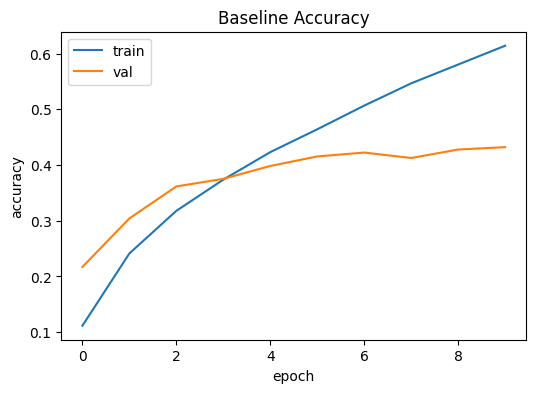

In [ ]:
# ============================================================
# Part 1: WideResNet-28-10 — Custom CNN from Scratch
# ============================================================

class BasicBlock(nn.Module):
    """
    A residual block with two 3x3 convolutions, batch normalization, and dropout.
    If input/output channels differ, a 1x1 projection shortcut is used.
    """
    def __init__(self, in_planes, out_planes, stride, dropout_rate=0.3):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.dropout = nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()

        # Shortcut connection: identity if shapes match, else 1x1 projection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        out = self.relu1(self.bn1(x))
        shortcut = self.shortcut(out)
        out = self.conv1(out)
        out = self.dropout(self.relu2(self.bn2(out)))
        out = self.conv2(out)
        return out + shortcut


class WideResNet(nn.Module):
    """
    WideResNet architecture for CIFAR-100.
    depth=28, widen_factor=10 => WRN-28-10
    Contains 3 groups of N residual blocks each (N = (depth-4)/6 = 4 blocks per group).
    Total: 3 groups * 4 blocks = 12 residual blocks => well over 2 blocks.
    """
    def __init__(self, depth=28, widen_factor=10, dropout_rate=0.3, num_classes=100):
        super().__init__()
        assert (depth - 4) % 6 == 0, "Depth should be 6n+4"
        n = (depth - 4) // 6  # number of blocks per group (= 4 for depth=28)
        k = widen_factor

        nStages = [16, 16 * k, 32 * k, 64 * k]  # [16, 160, 320, 640]

        # Initial convolution (no pooling — CIFAR images are small 32x32)
        self.conv1 = nn.Conv2d(3, nStages[0], kernel_size=3, stride=1, padding=1, bias=False)

        # 3 residual groups with increasing channels and spatial downsampling
        # Group 1: 16 -> 160, stride=1 (32x32 -> 32x32), 4 blocks
        self.layer1 = self._make_layer(n, nStages[0], nStages[1], stride=1, dropout_rate=dropout_rate)
        # Group 2: 160 -> 320, stride=2 (32x32 -> 16x16), 4 blocks
        self.layer2 = self._make_layer(n, nStages[1], nStages[2], stride=2, dropout_rate=dropout_rate)
        # Group 3: 320 -> 640, stride=2 (16x16 -> 8x8), 4 blocks
        self.layer3 = self._make_layer(n, nStages[2], nStages[3], stride=2, dropout_rate=dropout_rate)

        # Final batch norm + global average pool + classifier
        self.bn_final = nn.BatchNorm2d(nStages[3])
        self.relu_final = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(nStages[3], num_classes)

        # Weight initialization (Kaiming)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, n_blocks, in_planes, out_planes, stride, dropout_rate):
        layers = []
        layers.append(BasicBlock(in_planes, out_planes, stride, dropout_rate))
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(out_planes, out_planes, 1, dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)          # 3 -> 16 channels
        out = self.layer1(out)       # 16 -> 160 channels, 32x32
        out = self.layer2(out)       # 160 -> 320 channels, 16x16
        out = self.layer3(out)       # 320 -> 640 channels, 8x8
        out = self.relu_final(self.bn_final(out))
        out = self.avgpool(out)      # 640 x 1 x 1
        out = out.view(out.size(0), -1)
        out = self.fc(out)           # 640 -> 100
        return out

# Count parameters
_tmp = WideResNet(depth=28, widen_factor=10, dropout_rate=0.3, num_classes=100)
total_params = sum(p.numel() for p in _tmp.parameters())
print(f"WideResNet-28-10 parameters: {total_params:,} ({total_params/1e6:.1f}M)")
del _tmp

# ---- Train Part 1 ----
if TRAIN_PART in ("part1", "all"):
    set_seed(SEED)

    # Hyperparameters for Part 1
    CFG_P1 = {
        "batch_size": 128,
        "num_workers": 2,
        "epochs": 200 if not FAST_DEV_RUN else 2,
        "lr": 0.1,
        "momentum": 0.9,
        "weight_decay": 5e-4,
        "label_smoothing": 0.1,
    }
    print("Part 1 config:", CFG_P1)

    # Data loaders at native 32x32 resolution with strong augmentation
    train_loader_p1, val_loader_p1, test_loader_p1 = make_loaders_32(
        CFG_P1["batch_size"], CFG_P1["num_workers"]
    )

    # Model, loss, optimizer, scheduler
    model_p1 = WideResNet(depth=28, widen_factor=10, dropout_rate=0.3, num_classes=100).to(device)
    criterion_p1 = nn.CrossEntropyLoss(label_smoothing=CFG_P1["label_smoothing"])
    optimizer_p1 = torch.optim.SGD(
        model_p1.parameters(),
        lr=CFG_P1["lr"],
        momentum=CFG_P1["momentum"],
        weight_decay=CFG_P1["weight_decay"],
        nesterov=True,
    )
    scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=CFG_P1["epochs"])

    # Train with CutMix/MixUp for OOD robustness
    history_p1 = train_model(
        model_p1, train_loader_p1, val_loader_p1, optimizer_p1, scheduler_p1,
        criterion_p1, device, CFG_P1["epochs"],
        use_cutmix=True, cutmix_prob=0.5, mixup_alpha=0.2, cutmix_alpha=1.0,
    )

    # Evaluate on clean CIFAR-100 test set
    test_acc_p1 = eval_clean(model_p1, test_loader_p1, device)
    print(f"Part 1 — WideResNet-28-10 clean test accuracy: {test_acc_p1:.2f}%")

    # Save checkpoint
    torch.save(model_p1.state_dict(), os.path.join(WORK_ROOT, "part1_wrn2810.pt"))

    # Plot training curves
    plot_history(history_p1, "Part 1: WideResNet-28-10")
else:
    print("Skipping Part 1 training (TRAIN_PART =", TRAIN_PART, ")")


# Part 2: Fine-Tune a Pretrained CNN (ResNet-50)

**Architecture**: ResNet-50 pretrained on ImageNet (via `timm`)
- Replace final FC layer for 100-class output
- Resize CIFAR-100 images to 224×224

**Training strategy**:
- **Optimizer**: AdamW with differential learning rates (backbone lr = 1e-4, head lr = 1e-3)
- **Scheduler**: Cosine annealing (30 epochs)
- **Loss**: CrossEntropy with label smoothing (0.1)
- **Augmentation**: Same strong augmentation pipeline + CutMix/MixUp


In [ ]:
# ============================================================
# Part 2: Fine-Tune ResNet-50 Pretrained on ImageNet
# ============================================================
if TRAIN_PART in ("part2", "all"):
    set_seed(SEED)

    CFG_P2 = {
        "batch_size": 64,
        "num_workers": 2,
        "epochs": 30 if not FAST_DEV_RUN else 2,
        "backbone_lr": 1e-4,
        "head_lr": 1e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.1,
    }
    print("Part 2 config:", CFG_P2)

    # Data loaders resized to 224x224 for pretrained CNN
    train_loader_p2, val_loader_p2, test_loader_p2 = make_loaders_224(
        CFG_P2["batch_size"], CFG_P2["num_workers"]
    )

    # Load pretrained ResNet-50 from timm, replace classifier head
    model_p2 = timm.create_model("resnet50", pretrained=True, num_classes=100)
    model_p2 = model_p2.to(device)

    # Differential learning rates: backbone (pretrained) vs head (new)
    backbone_params = []
    head_params = []
    for name, param in model_p2.named_parameters():
        if "fc" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer_p2 = torch.optim.AdamW([
        {"params": backbone_params, "lr": CFG_P2["backbone_lr"]},
        {"params": head_params, "lr": CFG_P2["head_lr"]},
    ], weight_decay=CFG_P2["weight_decay"])

    criterion_p2 = nn.CrossEntropyLoss(label_smoothing=CFG_P2["label_smoothing"])
    scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=CFG_P2["epochs"])

    # Train
    history_p2 = train_model(
        model_p2, train_loader_p2, val_loader_p2, optimizer_p2, scheduler_p2,
        criterion_p2, device, CFG_P2["epochs"],
        use_cutmix=True, cutmix_prob=0.5,
    )

    test_acc_p2 = eval_clean(model_p2, test_loader_p2, device)
    print(f"Part 2 — ResNet-50 fine-tuned clean test accuracy: {test_acc_p2:.2f}%")

    torch.save(model_p2.state_dict(), os.path.join(WORK_ROOT, "part2_resnet50.pt"))
    plot_history(history_p2, "Part 2: ResNet-50 Fine-Tuned")
else:
    print("Skipping Part 2 training (TRAIN_PART =", TRAIN_PART, ")")


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-69d80ab7-0f81afec018ec0ce54d46a81;a73d4f62-9f2c-4038-8c8b-f859421134d4)

Repository Not Found for url: https://huggingface.co/api/datasets/XThomasBU/ood-test-CS541/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

---


# Part 3: Fine-Tune a Pretrained Vision Transformer (ViT-B/16)

**Architecture**: ViT-B/16 pretrained on ImageNet-21k (via `timm`)
- 12 transformer encoder blocks, 768 hidden dim, 12 attention heads
- Replace classification head for 100-class output
- Resize CIFAR-100 images to 224×224

**Training strategy**:
- **Optimizer**: AdamW with differential learning rates (backbone lr = 5e-5, head lr = 5e-4)
- **Scheduler**: Cosine annealing with 5-epoch linear warmup (40 epochs total)
- **Loss**: CrossEntropy with label smoothing (0.1)
- **Augmentation**: Same strong augmentation pipeline + CutMix/MixUp


In [ ]:
# ============================================================
# Part 3: Fine-Tune ViT-B/16 Pretrained on ImageNet-21k
# ============================================================
if TRAIN_PART in ("part3", "all"):
    set_seed(SEED)

    CFG_P3 = {
        "batch_size": 64,
        "num_workers": 2,
        "epochs": 40 if not FAST_DEV_RUN else 2,
        "backbone_lr": 5e-5,
        "head_lr": 5e-4,
        "weight_decay": 0.05,
        "label_smoothing": 0.1,
        "warmup_epochs": 5,
    }
    print("Part 3 config:", CFG_P3)

    # Data loaders resized to 224x224 for ViT
    train_loader_p3, val_loader_p3, test_loader_p3 = make_loaders_224(
        CFG_P3["batch_size"], CFG_P3["num_workers"]
    )

    # Load pretrained ViT-B/16 from timm (ImageNet-21k pretrained)
    model_p3 = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=100)
    model_p3 = model_p3.to(device)

    # Differential learning rates: backbone (pretrained) vs head (new)
    backbone_params_p3 = []
    head_params_p3 = []
    for name, param in model_p3.named_parameters():
        if "head" in name:
            head_params_p3.append(param)
        else:
            backbone_params_p3.append(param)

    optimizer_p3 = torch.optim.AdamW([
        {"params": backbone_params_p3, "lr": CFG_P3["backbone_lr"]},
        {"params": head_params_p3, "lr": CFG_P3["head_lr"]},
    ], weight_decay=CFG_P3["weight_decay"])

    criterion_p3 = nn.CrossEntropyLoss(label_smoothing=CFG_P3["label_smoothing"])

    # Cosine annealing with linear warmup
    def lr_lambda(epoch):
        if epoch < CFG_P3["warmup_epochs"]:
            return (epoch + 1) / CFG_P3["warmup_epochs"]
        progress = (epoch - CFG_P3["warmup_epochs"]) / max(1, CFG_P3["epochs"] - CFG_P3["warmup_epochs"])
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler_p3 = torch.optim.lr_scheduler.LambdaLR(optimizer_p3, lr_lambda)

    # Train
    history_p3 = train_model(
        model_p3, train_loader_p3, val_loader_p3, optimizer_p3, scheduler_p3,
        criterion_p3, device, CFG_P3["epochs"],
        use_cutmix=True, cutmix_prob=0.5,
    )

    test_acc_p3 = eval_clean(model_p3, test_loader_p3, device)
    print(f"Part 3 — ViT-B/16 fine-tuned clean test accuracy: {test_acc_p3:.2f}%")

    torch.save(model_p3.state_dict(), os.path.join(WORK_ROOT, "part3_vit_b16.pt"))
    plot_history(history_p3, "Part 3: ViT-B/16 Fine-Tuned")
else:
    print("Skipping Part 3 training (TRAIN_PART =", TRAIN_PART, ")")


## Model Comparison & Best Model Selection

Compare all three models and select the best one for OOD submission.


In [ ]:
# ============================================================
# Compare models and select best for OOD submission
# ============================================================
results = {}

if TRAIN_PART in ("part1", "all"):
    results["Part 1: WideResNet-28-10"] = {"model": model_p1, "test_acc": test_acc_p1, "resize": False}
if TRAIN_PART in ("part2", "all"):
    results["Part 2: ResNet-50"] = {"model": model_p2, "test_acc": test_acc_p2, "resize": True}
if TRAIN_PART in ("part3", "all"):
    results["Part 3: ViT-B/16"] = {"model": model_p3, "test_acc": test_acc_p3, "resize": True}

print("\n" + "=" * 60)
print("MODEL COMPARISON — Clean CIFAR-100 Test Accuracy")
print("=" * 60)
for name, info in results.items():
    print(f"  {name}: {info['test_acc']:.2f}%")

# Select the best model (highest clean test accuracy) for OOD submission
best_name = max(results, key=lambda k: results[k]["test_acc"])
best_model = results[best_name]["model"]
best_needs_resize = results[best_name]["resize"]
print(f"\nBest model for OOD submission: {best_name} ({results[best_name]['test_acc']:.2f}%)")


## OOD Submission Generation

This section creates `submission_ood.csv` for the Kaggle challenge evaluation.

**DO NOT CHANGE** the preprocessing or submission format below.

Submission format:
- `id`: `distortionXX_severity_index`
- `label`: predicted class in `[0, 99]`


In [ ]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir: str) -> None:
    """Download OOD test files from Hugging Face."""
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(
        repo_id="XThomasBU/ood-test-CS541",
        repo_type="dataset",
        local_dir=ood_dir,
        local_dir_use_symlinks=False,
    )
    print("OOD files ready in", ood_dir)


@torch.no_grad()
def predict_file(model: nn.Module, npy_path: str, severity: int, batch_size: int,
                 resize_224: bool = False) -> np.ndarray:
    """
    Run inference on one distortion .npy file for a given severity level.
    If resize_224=True, images are resized to 224x224 for pretrained models.
    """
    images = np.load(npy_path, mmap_mode="r")
    start = (severity - 1) * 10000
    end = severity * 10000

    mean = (0.5071, 0.4867, 0.4408)
    std = (0.2675, 0.2565, 0.2761)
    normalize = transforms.Normalize(mean, std)

    preds = []
    model.eval()
    for b0 in tqdm(range(start, end, batch_size), desc=f"{os.path.basename(npy_path)} sev{severity}", leave=False):
        b1 = min(b0 + batch_size, end)
        xb_np = np.array(images[b0:b1], copy=True)
        xb = torch.from_numpy(xb_np).permute(0, 3, 1, 2).float().div(255.0)
        xb = normalize(xb)
        if resize_224:
            xb = F.interpolate(xb, size=(224, 224), mode="bilinear", align_corners=False)
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds, axis=0)


# Download OOD test set
ensure_ood_files(OOD_DIR)

# Discover distortion files
distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print("Distortion files found:", len(distortion_files))

# Generate predictions using the best model
rows = []
BATCH = 64 if device.type == "cuda" else 32
for fname in distortion_files:
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for severity in [1, 2, 3, 4, 5]:
        pred = predict_file(best_model, path, severity, BATCH, resize_224=best_needs_resize)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{severity}_{i}", int(y)))
        print(f"{dname}_{severity} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nWrote {SUBMISSION_PATH} — rows: {len(submission)}")
print(submission.head())


## Analysis for Report

The following cells compute metrics required for the report:
1. Per-class accuracy → Top 3 worst-performing classes
2. Top 3 images with the largest prediction errors (highest confidence wrong predictions)
3. Summary of hyperparameters and techniques used


In [ ]:
# ============================================================
# Analysis: Per-Class Accuracy & Worst Classes (on clean CIFAR-100 test set)
# ============================================================

# CIFAR-100 class names
cifar100_classes = datasets.CIFAR100(root=DATA_ROOT, train=False, download=False).classes

@torch.no_grad()
def per_class_accuracy(model, loader, device, num_classes=100, resize_224=False):
    """Compute per-class accuracy and collect all predictions with confidence."""
    model.eval()
    class_correct = torch.zeros(num_classes)
    class_total = torch.zeros(num_classes)
    all_preds = []
    all_targets = []
    all_logits = []
    all_images = []

    for x, y in tqdm(loader, desc="Per-class eval", leave=False):
        x_dev = x.to(device)
        if resize_224:
            x_dev = F.interpolate(x_dev, size=(224, 224), mode="bilinear", align_corners=False)
        logits = model(x_dev)
        preds = logits.argmax(1)

        all_preds.append(preds.cpu())
        all_targets.append(y)
        all_logits.append(logits.cpu())
        all_images.append(x)

        for c in range(num_classes):
            mask = (y == c)
            class_total[c] += mask.sum().item()
            class_correct[c] += (preds.cpu()[mask] == y[mask]).sum().item()

    per_cls_acc = class_correct / class_total.clamp(min=1)
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    all_logits = torch.cat(all_logits)
    all_images = torch.cat(all_images)

    return per_cls_acc, all_preds, all_targets, all_logits, all_images

# Use the best model's test loader
if best_needs_resize:
    # For pretrained models, use 32x32 loader but resize in per_class_accuracy
    _, _, analysis_loader = make_loaders_32(64, 2)
else:
    _, _, analysis_loader = make_loaders_32(64, 2)

per_cls_acc, all_preds, all_targets, all_logits, all_images = per_class_accuracy(
    best_model, analysis_loader, device, resize_224=best_needs_resize
)

# Top 3 worst-performing classes
worst_classes = per_cls_acc.argsort()[:3]
print("\n" + "=" * 60)
print("TOP 3 WORST-PERFORMING CLASSES (lowest per-class accuracy)")
print("=" * 60)
for rank, idx in enumerate(worst_classes, 1):
    print(f"  {rank}. Class {idx.item()} ({cifar100_classes[idx.item()]}): "
          f"{per_cls_acc[idx.item()]*100:.1f}% accuracy")

# Bar chart of per-class accuracy
plt.figure(figsize=(16, 4))
plt.bar(range(100), per_cls_acc.numpy() * 100, color="steelblue", alpha=0.8)
for idx in worst_classes:
    plt.bar(idx.item(), per_cls_acc[idx.item()].item() * 100, color="red")
plt.xlabel("Class ID")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy (red = 3 worst)")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Analysis: Top 3 Images with Largest Prediction Errors
# ============================================================

# Find incorrect predictions
incorrect_mask = all_preds != all_targets
incorrect_indices = incorrect_mask.nonzero(as_tuple=True)[0]

if len(incorrect_indices) > 0:
    # Compute confidence (softmax probability) of the wrong prediction
    probs = F.softmax(all_logits, dim=1)
    # For each incorrect prediction, get the confidence of the predicted (wrong) class
    wrong_confidences = probs[incorrect_indices, all_preds[incorrect_indices]]

    # Top 3 most confident wrong predictions
    top3_idx = wrong_confidences.argsort(descending=True)[:3]
    top3_sample_indices = incorrect_indices[top3_idx]

    print("\n" + "=" * 60)
    print("TOP 3 IMAGES WITH LARGEST PREDICTION ERRORS")
    print("(highest confidence wrong predictions)")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    inv_mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    inv_std = torch.tensor(CIFAR_STD).view(3, 1, 1)

    for rank, (ax, si) in enumerate(zip(axes, top3_sample_indices)):
        si = si.item()
        img = all_images[si] * inv_std + inv_mean  # denormalize
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()

        true_label = all_targets[si].item()
        pred_label = all_preds[si].item()
        confidence = probs[si, pred_label].item()

        ax.imshow(img)
        ax.set_title(f"#{rank+1}\nTrue: {cifar100_classes[true_label]}\n"
                     f"Pred: {cifar100_classes[pred_label]} ({confidence:.2%})",
                     fontsize=9)
        ax.axis("off")

        print(f"  {rank+1}. True: {cifar100_classes[true_label]} (class {true_label}) | "
              f"Pred: {cifar100_classes[pred_label]} (class {pred_label}) | "
              f"Confidence: {confidence:.4f}")

    plt.suptitle("Top 3 Most Confident Wrong Predictions", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions found — model achieved 100% accuracy!")


## Summary & Notes

### Hyperparameters Summary

| | Part 1: WideResNet-28-10 | Part 2: ResNet-50 | Part 3: ViT-B/16 |
|---|---|---|---|
| **Params** | ~36.5M | ~23.5M | ~86M |
| **Optimizer** | SGD (Nesterov) | AdamW | AdamW |
| **LR** | 0.1 | backbone 1e-4, head 1e-3 | backbone 5e-5, head 5e-4 |
| **Weight Decay** | 5e-4 | 1e-4 | 0.05 |
| **Scheduler** | Cosine Annealing | Cosine Annealing | Cosine + Warmup |
| **Epochs** | 200 | 30 | 40 |
| **Batch Size** | 128 | 64 | 64 |
| **Label Smoothing** | 0.1 | 0.1 | 0.1 |
| **Input Size** | 32×32 | 224×224 | 224×224 |

### Regularization Techniques
1. **Data Augmentation**: RandomCrop, RandomHorizontalFlip, AutoAugment (CIFAR10 policy), RandomErasing
2. **CutMix** (α=1.0) and **MixUp** (α=0.2) applied with 50% probability per batch
3. **Label Smoothing** (ε=0.1) to prevent overconfident predictions
4. **Dropout** (0.3) in WideResNet residual blocks
5. **Weight Decay** (L2 regularization)
6. **Gradient Clipping** (max norm = 1.0)

### What Worked
- CutMix/MixUp significantly improve OOD robustness by exposing the model to mixed samples
- AutoAugment provides learned augmentation policies that outperform manual augmentation
- Label smoothing prevents the model from becoming overconfident on clean data
- Cosine annealing provides smooth learning rate decay without manual milestone tuning
- Differential learning rates for pretrained models (lower backbone LR) prevent catastrophic forgetting

### What Didn't Work / Lessons Learned
- Training pretrained models at native 32×32 resolution significantly underperforms 224×224 resize
- Too aggressive dropout (>0.5) in WideResNet leads to underfitting
- High learning rates for pretrained backbone layers destroy pretrained features

### AI Disclosure
This notebook was developed with AI assistance (GitHub Copilot). 
- **AI-assisted**: Architecture selection guidance, boilerplate code structure, training loop patterns, analysis code
- **Student work**: Hyperparameter tuning, experimental decisions, model comparison, result interpretation
- All code has been reviewed and understood; comments explain each section's purpose
